In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from misc import load_model_best_config, make_config_object
from models.utils import get_autoencoder_model
import config
from data_preproc.data_preproc_functions import Logger
logger=Logger()




C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_7388\3704809938.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
batch_size = 8
input_size = (batch_size,1,96,96,96)

batch_size, channels, depth, height, width = input_size

config.model_name = "swin3d_small"
config.use_best_config = False
config.n_input_channels = 1


config = make_config_object(config)

model = get_autoencoder_model(config, channels, depth, height, width, n_features=0, logger=logger, save_summary=False)



c:\Users\d.c.macrae\.conda\envs\HNC_310\lib\site-packages\torch\functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Layer (type (var_name))                                 Input Shape               Output Shape              Param #                   Kernel Shape
MultiTox_Autoencoder (MultiTox_Autoencoder)             [8, 1, 96, 96, 96]        [8, 1, 96, 96, 96]        --                        --
├─SwinTransformer3D (encoder)                           [8, 1, 96, 96, 96]        [8, 768, 3, 3, 3]         --                        --
│    └─PatchEmbed3D (patch_embed)                       [8, 1, 96, 96, 96]        [8, 96, 24, 24, 24]       --                        --
│    │    └─Conv3d (proj)                               [8, 1, 96, 96, 96]        [8, 96, 24, 24, 24]       6,240                     [4, 4, 4]
│    └─Dropout (pos_drop)                               [8, 96, 24, 24, 24]       [8, 96, 24, 24, 24]       --                        --
│    └─ModuleList (layers)                              --                        --                        --                        --
│    │    └─BasicLayer (

In [77]:



class M3D_Seg(Dataset):
    """
    A Pytorch Dataset class for the M3D Segmentation dataset.
    In train mode, random crops are taken from the data samples. In test mode, the center crop is taken.
    """
    def __init__(self, data_folder_dir, crop_size = 96, random_cropping=False, masked=False, test_mode=False):
        self.data_folder = data_folder_dir
        self.data_samples = os.listdir(data_folder_dir)
        #self.data = data
        self.crop_size = crop_size
        self.random_cropping = random_cropping
        self.test_mode = test_mode
        self.masked = masked

        if test_mode:
            self.data_samples = self.data_samples[:32]

    def __len__(self):
        return len(self.data_samples)

    def __getitem__(self, index):
        # Return a single data sample
        data = np.load(os.path.join(self.data_folder, self.data_samples[index]))
        data = torch.tensor(data, dtype=torch.float32) # turn into tensor and remove the first dimension
        # Get the shape of the data tensor
        data_shape = data.shape

        # if training mode, crop a random 96x96x96 cube from the data tensor
        if self.random_cropping:
            # Generate random coordinates for the starting point of the cube
            start_x = random.randint(0, data_shape[1] - self.crop_size)
            start_y = random.randint(0, data_shape[2] - self.crop_size)
            start_z = random.randint(0, data_shape[3] - self.crop_size)

            # Crop the cube from the data tensor
            #cropped_cube = data[:, start_x:start_x+self.crop_size, start_y:start_y+self.crop_size, start_z:start_z+self.crop_size]
        
        # if test mode, crop the 96x96x96 cube from the center data tensor
        else:
            # Crop the cube from the center of the data tensor
            start_x = (data_shape[1] - self.crop_size) // 2
            start_y = (data_shape[2] - self.crop_size) // 2
            start_z = (data_shape[3] - self.crop_size) // 2

    
        # Crop the cube from the data tensor
        cropped_cube = data[:, start_x:start_x+self.crop_size, start_y:start_y+self.crop_size, start_z:start_z+self.crop_size]

        # if training a masked autoencoder, randomly drop 20% of the blocks in the cube
        if self.masked:
            masked_cube = cropped_cube.clone()

            block_size = 12
            num_blocks_per_axis = 8

            total_blocks = num_blocks_per_axis ** 3

            # randomly select 20% of these blocks to drop
            num_blocks_to_drop = int(0.2 * total_blocks)
            zero_block_indices = torch.randint(0, total_blocks, (num_blocks_to_drop,), device=config.device)

            # convert to 3d coords
            zero_block_indices_3d = torch.stack([zero_block_indices % num_blocks_per_axis,
                                                    (zero_block_indices // num_blocks_per_axis) % num_blocks_per_axis,
                                                    zero_block_indices // (num_blocks_per_axis ** 2)], dim=1)

            zero_block_indices_3d = zero_block_indices_3d * block_size
            #zero_block_indices_3d = zero_block_indices_3d.T

            for coord in zero_block_indices_3d:
                masked_cube[:, coord[0]:coord[0]+block_size, coord[1]:coord[1]+block_size, coord[2]:coord[2]+block_size] = 0

            return masked_cube, cropped_cube
        
        else:
            return cropped_cube, cropped_cube


# Create your dataset
TEST_MODE = True

train_dataset = M3D_Seg('datasets/M3D_Seg/train', crop_size=96, random_cropping=True, masked=True, test_mode=TEST_MODE)
test_dataset = M3D_Seg('datasets/M3D_Seg/test', crop_size=96, random_cropping=False, masked=True, test_mode=TEST_MODE)


# Create a DataLoader
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,  num_workers=4, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



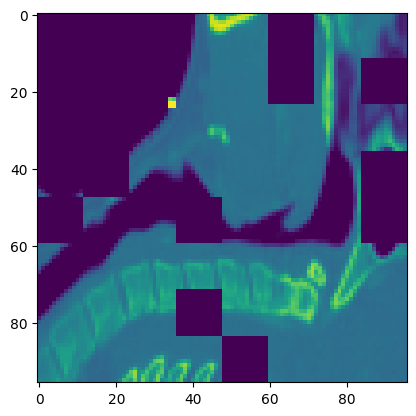

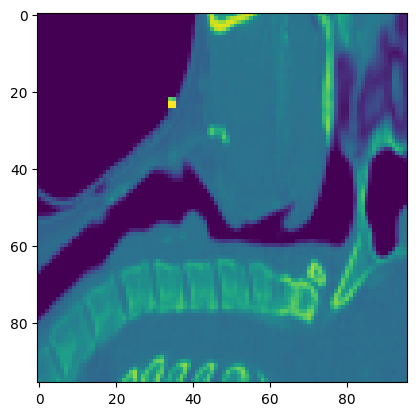

In [79]:
with torch.no_grad():
    for input, target in test_dataloader:
        #print(batch.shape)
        input = input.to(config.device)
        #outputs = model(batch)
        #loss = loss_function(outputs, batch)
        
        #val_loss += loss.item() * batch.shape[0]

plt.imshow(input[3,0,50,:,:].cpu())
plt.show()

plt.imshow(target[3,0,50,:,:].cpu())
plt.show()

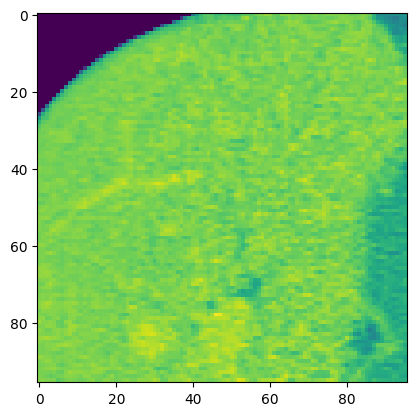

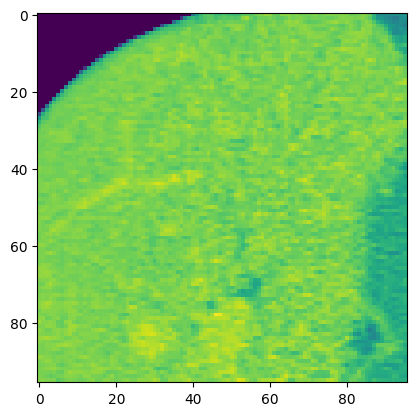

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
%matplotlib inline
import matplotlib.pyplot as plt


tensor1 = batch[0,0,:,:,:]
tensor2 = tensor1.clone()

# Calculate the number of cubes to drop
num_cubes_to_drop = int(0.5 * (96 // 8) ** 3)

# Generate random coordinates for the cubes to drop
drop_indices = torch.randperm(96 // 8, device=config.device)[:num_cubes_to_drop]

# Create a mask to drop the cubes
mask = torch.ones((96, 96, 96), device=config.device)
for i in drop_indices:
    start_x = i % (96 // 8) * 8
    start_y = (i // (96 // 8)) % (96 // 8) * 8
    start_z = (i // (96 // 8) // (96 // 8)) % (96 // 8) * 8
    mask[start_x:start_x+8, start_y:start_y+8, start_z:start_z+8] = 0

# Apply the mask to the tensor
tensor2 = tensor1 * mask

plt.imshow(tensor1[50,:,:].cpu())
plt.show()

plt.imshow(tensor2[50,:,:].cpu())
plt.show()

In [67]:
tensor1 = batch[2,0,:,:,:]
tensor2 = tensor1.clone()

block_size = 12
num_blocks_per_axis = 8

total_blocks = num_blocks_per_axis ** 3

# randomly select 20% of these blocks to drop
num_blocks_to_drop = int(0.2 * total_blocks)
zero_block_indices = torch.randint(0, total_blocks, (num_blocks_to_drop,), device=config.device)

# convert to 3d coords
zero_block_indices_3d = torch.stack([zero_block_indices % num_blocks_per_axis,
                                        (zero_block_indices // num_blocks_per_axis) % num_blocks_per_axis,
                                        zero_block_indices // (num_blocks_per_axis ** 2)], dim=1)

zero_block_indices_3d = zero_block_indices_3d * block_size
#zero_block_indices_3d = zero_block_indices_3d.T

for coord in zero_block_indices_3d:
    tensor2[coord[0]:coord[0]+block_size, coord[1]:coord[1]+block_size, coord[2]:coord[2]+block_size] = 0


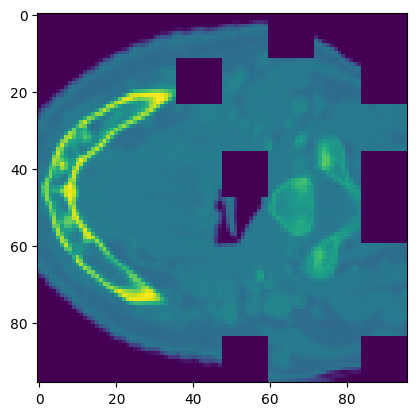

In [68]:
plt.imshow(tensor2[:,:,50].cpu())
plt.show()

In [5]:
batch.shape


torch.Size([32, 1, 96, 96, 96])

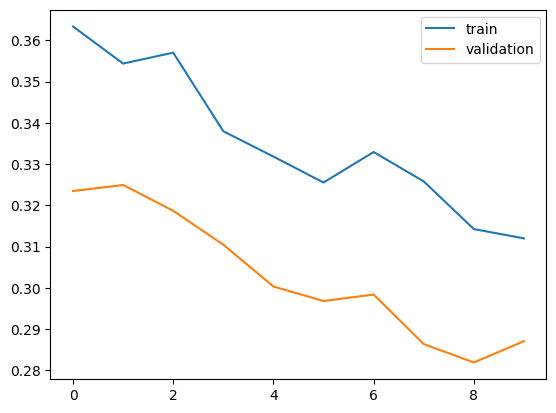

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.legend()
plt.show()



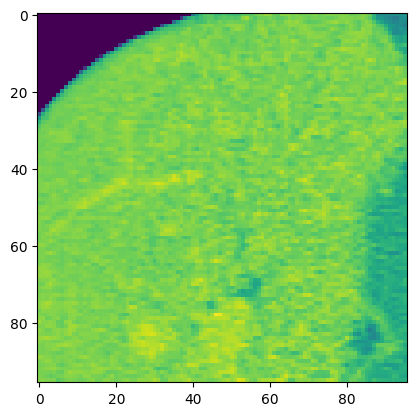

In [19]:
outputs.shape

torch.Size([2, 1, 96, 96, 96])

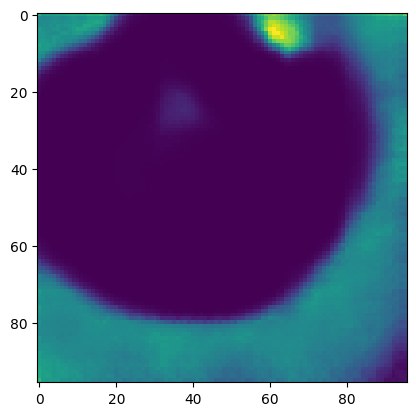

In [20]:

plt.imshow(outputs[0,0,:,:,50].cpu().detach().numpy())
plt.show()

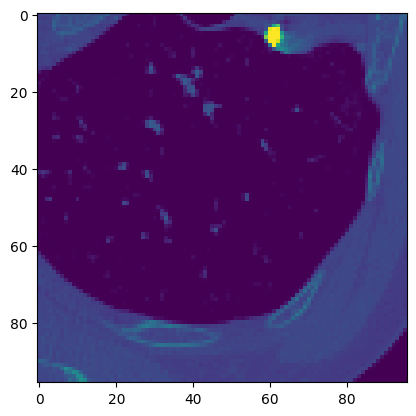

In [21]:
plt.imshow(batch[0,0,:,:,50].cpu().detach().numpy())
plt.show()